# Student Segmentation and Personalized Course Recommendation System for EduPro

In [60]:
import warnings
warnings.filterwarnings("ignore")

In [61]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Load Dataset

In [62]:
df=pd.read_csv("EduPro_Online_Platform_Users.csv")

In [63]:
df.head()

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [64]:
df.tail()

,UserID,UserName,Age,Gender,Email
2995,U02996,rebeccamccoy,32,Male,james28@outlook.com
2996,U02997,jburke,21,Female,nramos@yahoo.com
2997,U02998,choikendra,33,Male,katherinebeck@hotmail.com
2998,U02999,rachelmalone,20,Male,rodgerserica@hotmail.com
2999,U03000,harperdouglas,15,Male,jackie41@gmail.com


### Dataset Information

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


In [66]:
df.describe()

,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


In [67]:
df.shape

(3000, 5)

In [68]:
df.columns

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')

### Missing Values

In [69]:
df.isnull().sum()

UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

### Duplicate Records

In [70]:
df.duplicated().sum()

np.int64(0)

### Gender Distribution

In [71]:
df["Gender"].value_counts()

Gender
Female    1520
Male      1480
Name: count, dtype: int64

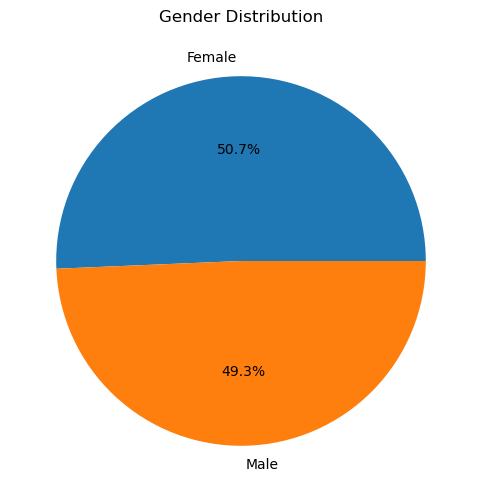

In [72]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

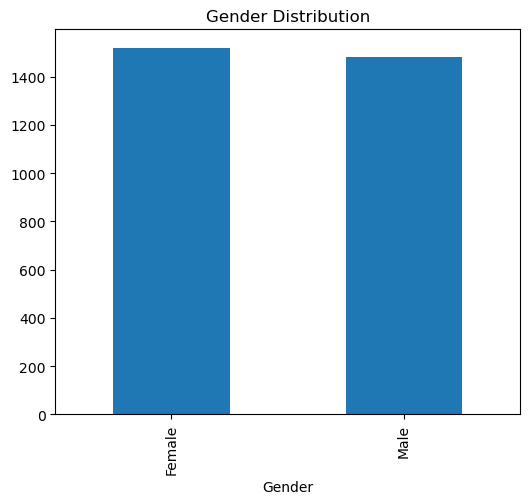

In [73]:
plt.figure(figsize=(6,5))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

### Age Distribution

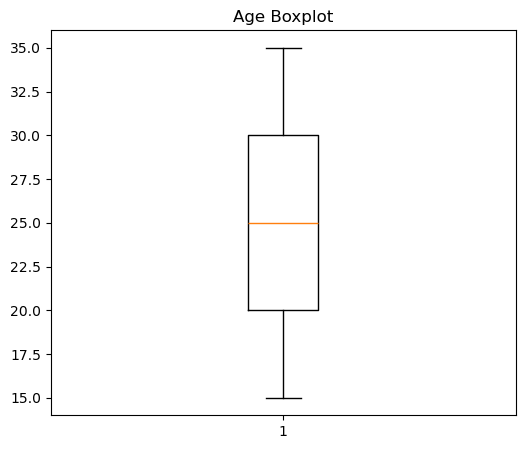

In [74]:
plt.figure(figsize=(6,5))
plt.boxplot(df["Age"])
plt.title("Age Boxplot")
plt.show()

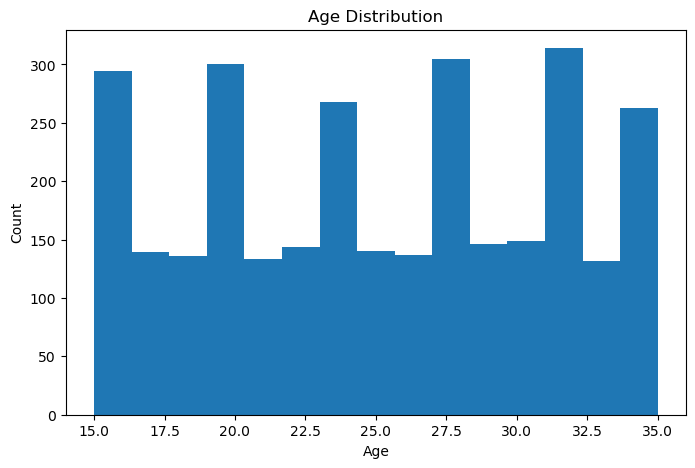

In [75]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=15)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

### Age Group

In [76]:
bins=[0,18,25,35,45,60]
labels=["Teen","Young Adult","Adult","Middle Age","Senior"]
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)
df["AgeGroup"].value_counts()

AgeGroup
Adult          1446
Young Adult     985
Teen            569
Middle Age        0
Senior            0
Name: count, dtype: int64

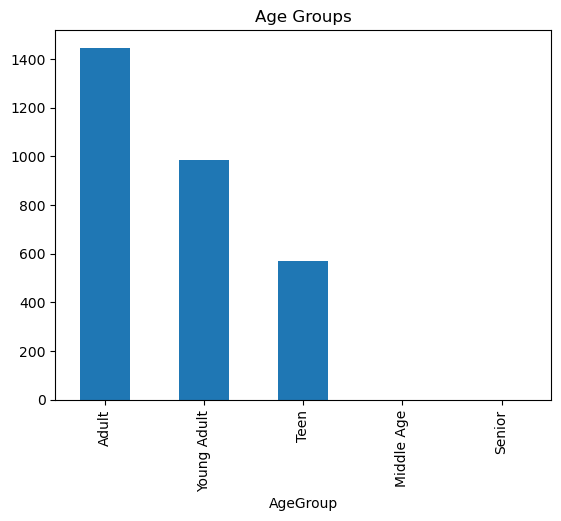

In [77]:
df["AgeGroup"].value_counts().plot(kind="bar")
plt.title("Age Groups")
plt.show()

### Encode Gender

In [78]:
encoder=LabelEncoder()
df["Gender"]=encoder.fit_transform(df["Gender"])

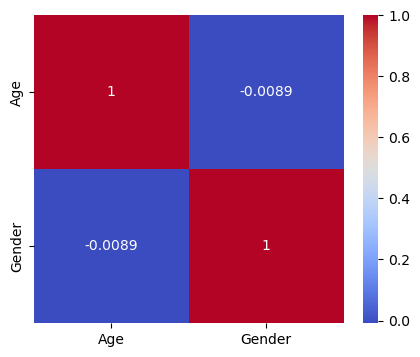

In [79]:
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(
    df[["Age","Gender"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

### Select Features

In [80]:
X=df[["Age","Gender"]]

### Scale Data

In [81]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### Elbow Method

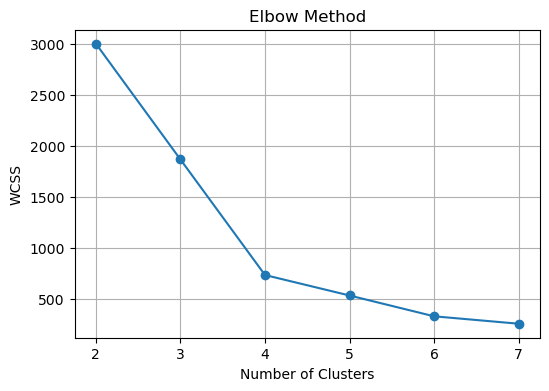

In [82]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2, 8):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,8), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [83]:
#Observation:
#The elbow appears at K = 3.
#Therefore, the optimal number of clusters selected is 3.

### Train K-Means

In [84]:
kmeans=KMeans(n_clusters=3,random_state=42)
df["Cluster"]=kmeans.fit_predict(X_scaled)

In [85]:
df.head()

,UserID,UserName,Age,Gender,Email,AgeGroup,Cluster
0,U00001,wilsonjordan,15,1,patricia27@hotmail.com,Teen,1
1,U00002,angela22,29,0,hallrandy@hotmail.com,Adult,0
2,U00003,morrisonamanda,33,0,ganderson@yahoo.com,Adult,0
3,U00004,fthornton,23,0,christensencatherine@outlook.com,Young Adult,2
4,U00005,fostergeoffrey,21,1,karenfuentes@yahoo.com,Young Adult,1


### Silhouette Score

In [86]:
score=silhouette_score(X_scaled,df["Cluster"])
print(score)

0.5434353153806845


In [87]:
#Observation: Silhouette Score close to 1 indicates well-separated clusters.

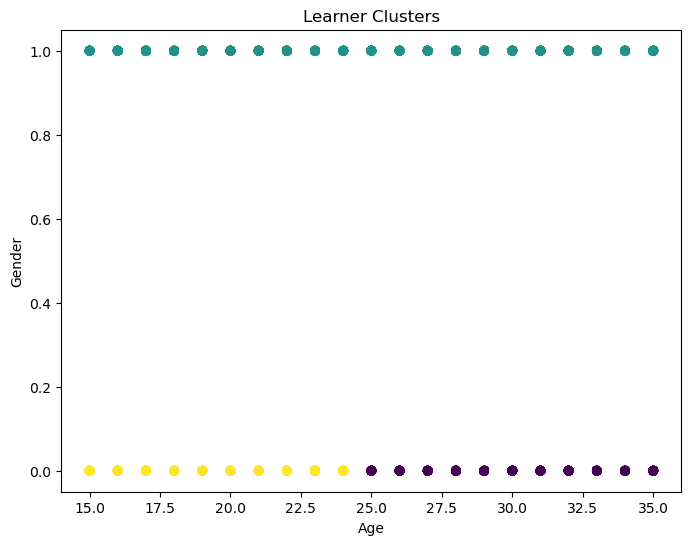

In [88]:
### Visualize Cluster
plt.figure(figsize=(8,6))
plt.scatter(df["Age"],df["Gender"],c=df["Cluster"])
plt.xlabel("Age")
plt.ylabel("Gender")
plt.title("Learner Clusters")
plt.show()

### Cluster Summary

In [89]:
cluster_summary = df.groupby("Cluster").agg({
"Age":["mean","min","max"],
"UserID":"count"
})
cluster_summary

Age         UserID
              mean min max  count
Cluster                          
0        29.909765  25  35    809
1        24.919595  15  35   1480
2        19.472574  15  24    711

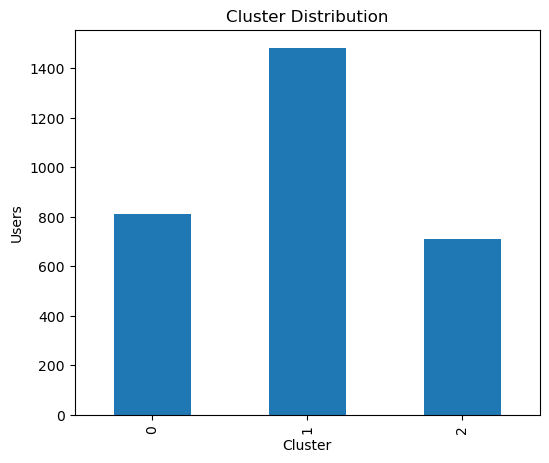

In [90]:
plt.figure(figsize=(6,5))
df["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.title("Cluster Distribution")
plt.show()

## Cluster Interpretation

### Cluster 0 – Young Learners
• Mostly students
• Beginner level
• Interested in learning fundamentals

### Cluster 1 – Career Builders
• Working professionals
• Skill enhancement
• Certification-oriented learning

### Cluster 2 – Experienced Learners
• Older learners
• Advanced learning
• Specialized topics

In [96]:
def recommend(cluster):

    if cluster == 0:
        return [
            "Python Basics",
            "Programming Fundamentals",
            "Introduction to AI",
            "Communication Skills"
        ]

    elif cluster == 1:
        return [
            "Data Analytics",
            "SQL",
            "Power BI",
            "Machine Learning"
        ]

    else:
        return [
            "Deep Learning",
            "Cloud Computing",
            "AI Projects",
            "Leadership Skills"
        ]

In [98]:
cluster_names = {
    0: "Young Learners",
    1: "Career Builders",
    2: "Experienced Learners"
}

df["LearnerType"] = df["Cluster"].map(cluster_names)

In [99]:
user = df.iloc[0]

print("User Name:", user["UserName"])

print("Age:", user["Age"])

print("Learner Type:", user["LearnerType"])

print("\nRecommended Learning Path:\n")

for course in recommend(user["Cluster"]):
    print("-", course)

User Name: wilsonjordan
Age: 15
Learner Type: Career Builders

Recommended Learning Path:

- Data Analytics
- SQL
- Power BI
- Machine Learning


### Saving the Model

In [102]:
import joblib

joblib.dump(kmeans,"kmeans.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [92]:
### Predicting New User
new_user=[[25,1]]

new_scaled=scaler.transform(new_user)

prediction=kmeans.predict(new_scaled)

print("Cluster:",prediction[0])

Cluster: 1


# Conclusion

The learner segmentation model successfully grouped users into meaningful demographic clusters using K-Means clustering. These learner segments provide a foundation for personalized learning experiences.

Although the provided dataset contains only demographic information (Age and Gender), the clustering model demonstrates how users can be categorized for targeted learning paths. In future work, integrating course enrollment and transaction history would enable a fully personalized recommendation system using collaborative and content-based filtering techniques.